# Librairies:

In [182]:
import mysql.connector as sql
import pandas as pd
import os
import matplotlib.pyplot as plt
import pandas as pad 
import statistics
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

# Exploration de la base de données :

In [185]:
df = pd.read_csv('clinical_data.csv', header=0, delimiter=';', decimal=',')

print("Noms des colonnes :", df.columns)

nombre_hommes = df[df['gender'] == 'M'].shape[0]
print("Nombre d'hommes :", nombre_hommes)
nombre_femmes = df[df['gender'] == 'F'].shape[0]
print("Nombre de femmes :", nombre_femmes)

print(df.iloc[:, 1:].head())


Noms des colonnes : Index(['id', 'surgery', 'OMS', 'survival', 'IDH', 'ATRK', 'gender'], dtype='object')
Nombre d'hommes : 101
Nombre de femmes : 75
      surgery  OMS  survival  IDH ATRK gender
0  incomplete    0       213  NaN  NaN      F
1      biopsy    2       307  NaN  NaN      M
2      biopsy    2       207  NaN  NaN      F
3  incomplete    1       493  NaN  NaN      F
4  incomplete    1       768  NaN  NaN      M


In [187]:
def perform_anova_analysis(df, variable):
    surgery_groups = [
        df[df['surgery'] == 'biopsy'][variable].dropna(),
        df[df['surgery'] == 'incomplete'][variable].dropna(),
        df[df['surgery'] == 'complete'][variable].dropna()
    ]

    f_statistic, p_value = f_oneway(*surgery_groups)

    print(f"ANOVA - Comparison of {variable} by surgery type:")
    print(f"F-statistic: {f_statistic}")
    print(f"p-value: {p_value}")
    
    print("\nDescriptive statistics:")
    for surgery_type in ['biopsy', 'incomplete', 'complete']:
        group = df[df['surgery'] == surgery_type][variable].dropna()
        print(f"\n{surgery_type.capitalize()}:")
        print(f"Number of patients: {len(group)}")
        print(f"Mean {variable}: {group.mean():.2f}")
        print(f"Standard deviation {variable}: {group.std():.2f}")

    if variable == 'survival':
        plt.figure(figsize=(10, 6))

        df['surgery_type'] = df['surgery'].replace({'incomplete': 'incomplete surgery', 'complete': 'complete surgery'})
        
        order = ['biopsy', 'incomplete surgery', 'complete surgery']
        
        summary_df = (
            df.groupby('surgery_type')[variable]
            .agg(['mean', 'std'])
            .reindex(order)
            .reset_index()
        )

        colors = ['#00244A', '#006A89', '#37B4AA']

        sns.barplot(x='surgery_type', y='mean', data=summary_df, errorbar=None, order=order, palette=colors)

        for i, (mean, std) in enumerate(zip(summary_df['mean'], summary_df['std'])):
            lower_error = mean - std
            upper_error = mean + std

            if lower_error < 0:
                lower_error = 0  
            if upper_error > mean:
                plt.plot([i, i], [mean, upper_error], color='black', linewidth=1)
                plt.plot([i - 0.1, i + 0.1], [upper_error, upper_error], color='black', linewidth=1)
            
            # Vérifie que l'astérisque est bien placé pour les chirurgies "incomplete" et "complete"
            if summary_df['surgery_type'].iloc[i] in ['incomplete surgery', 'complete surgery']:
                plt.text(i, upper_error - 10, '*', color='black', fontsize=20, ha='center')
        
        plt.figtext(0.5, -0.1, "Impact of surgery quality on overall survival: Mean ± SD, n=70 ; 62 ; 44 for biopsy, surgery incomplete, surgery complete respectively, * p < 0.05 vs biopsy'.", ha="center", va="top", fontsize=9)
        plt.subplots_adjust(bottom=-0.02, top=0.8)
        plt.xlabel('')
        plt.ylabel(f'{variable} (days)')
        plt.savefig('survival_distribution_by_surgery_type.png', bbox_inches='tight', dpi=150)
        plt.show()


In [189]:
def ExplorationDonneesPreliminaires_histplot_boxplot(df, colonne):

    custom_palette = ["#00244A", "#006A89", "#37B4AA"]
    
    df_femme = df[df['gender'] == 'F']
    df_homme = df[df['gender'] == 'M']

    print(f"Valeur minimale de {colonne} :", round(df[colonne].min(), 2))
    print(f"Valeur maximale de {colonne} :", round(df[colonne].max(), 2))
    print(f"Valeur moyenne de {colonne} :", round(df[colonne].mean(), 2))
    print(f"Valeur écart-type de {colonne} :", round(df[colonne].std(), 2))
        

    fig, axs = plt.subplots(2, 3, figsize=(20, 10))  
    sns.histplot(data=df, x=colonne, kde=False, ax=axs[0, 0], color=custom_palette[0]) 
    axs[0, 0].set_title('Globale')
    sns.histplot(data=df_femme, x=colonne, kde=False, ax=axs[0, 1], color=custom_palette[1]) 
    axs[0, 1].set_title('Femmes')
    sns.histplot(data=df_homme, x=colonne, kde=False, ax=axs[0, 2], color=custom_palette[2]) 
    axs[0, 2].set_title('Hommes')
        
    sns.boxplot(data=df, x=colonne, ax=axs[1, 0], color=custom_palette[0])
    sns.stripplot(data=df, x=colonne, dodge=True, ax=axs[1, 0], color="black", jitter=True)
    axs[1, 0].set_title('Globale')
    sns.boxplot(data=df_femme, x=colonne, ax=axs[1, 1], color=custom_palette[1])
    sns.stripplot(data=df_femme, x=colonne, dodge=True, ax=axs[1, 1], color="black", jitter=True)
    axs[1, 1].set_title('Femmes')
    sns.boxplot(data=df_homme, x=colonne, ax=axs[1, 2], color=custom_palette[2])
    sns.stripplot(data=df_homme, x=colonne, dodge=True, ax=axs[1, 2], color="black", jitter=True)
    axs[1, 2].set_title('Hommes')
        

    plt.tight_layout()
    plt.show()  
    
    fig.savefig(f'{colonne}_histo_boxplot.png')


In [191]:
def ExplorationDonneesPreliminaires_diagramme(df, colonne):  

    unique_values = df[colonne].nunique() 

    custom_palette = ["#00244A", "#006A89", "#37B4AA"]
    rocket_palette = sns.color_palette("viridis", unique_values)
    

    df_femme = df[df['gender'] == 'F']
    df_homme = df[df['gender'] == 'M']  

    data       = (df[colonne].value_counts() * 100) / len(df)
    data_femme = (df_femme[colonne].value_counts() * 100) / len(df_femme)
    data_homme = (df_homme[colonne].value_counts() * 100) / len(df_homme)
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 10)) 
    
    axs[0].pie(x=data, labels=data.index, colors=rocket_palette[:len(data)], autopct='%1.2f%%')
    axs[0].set_title(f"Répartition globale ({colonne})")
    axs[1].pie(x=data_femme, labels=data_femme.index, colors=rocket_palette[:len(data_femme)], autopct='%1.2f%%')
    axs[1].set_title(f"Répartition femmes ({colonne})")
    axs[2].pie(x=data_homme, labels=data_homme.index, colors=rocket_palette[:len(data_homme)], autopct='%1.2f%%')
    axs[2].set_title(f"Répartition hommes ({colonne})")
    
    plt.show()
    fig.savefig(f'{colonne}_diagramme.png')


In [193]:
def ExplorationDonneesPreliminaires_diagramme(df, colonne):  

    unique_values = df[colonne].nunique() 
    custom_palette = ["#00244A", "#006A89", "#37B4AA"]
    df_femme = df[df['gender'] == 'F']
    df_homme = df[df['gender'] == 'M']  
    data       = (df[colonne].value_counts() * 100) / len(df)
    data_femme = (df_femme[colonne].value_counts() * 100) / len(df_femme)
    data_homme = (df_homme[colonne].value_counts() * 100) / len(df_homme) 
    fig, axs = plt.subplots(1, 3, figsize=(20, 10)) 
    

    axs[0].pie(x=data, labels=data.index, colors=custom_palette[:len(data)], autopct='%1.2f%%', textprops={'color': 'black'})
    axs[0].set_title(f"Répartition globale ({colonne})", color='black')  # Titre en noir
    axs[1].pie(x=data_femme, labels=data_femme.index, colors=custom_palette[:len(data_femme)], autopct='%1.2f%%', textprops={'color': 'black'})
    axs[1].set_title(f"Répartition femmes ({colonne})", color='black')  # Titre en noir
    axs[2].pie(x=data_homme, labels=data_homme.index, colors=custom_palette[:len(data_homme)], autopct='%1.2f%%', textprops={'color': 'black'})
    axs[2].set_title(f"Répartition hommes ({colonne})", color='black')  # Titre en noir
    

    for ax in axs:
        for txt in ax.texts:
            if '%' in txt.get_text():
                txt.set_color('white')
    
    plt.show()
    fig.savefig(f'{colonne}_diagramme.png')

# Resultats

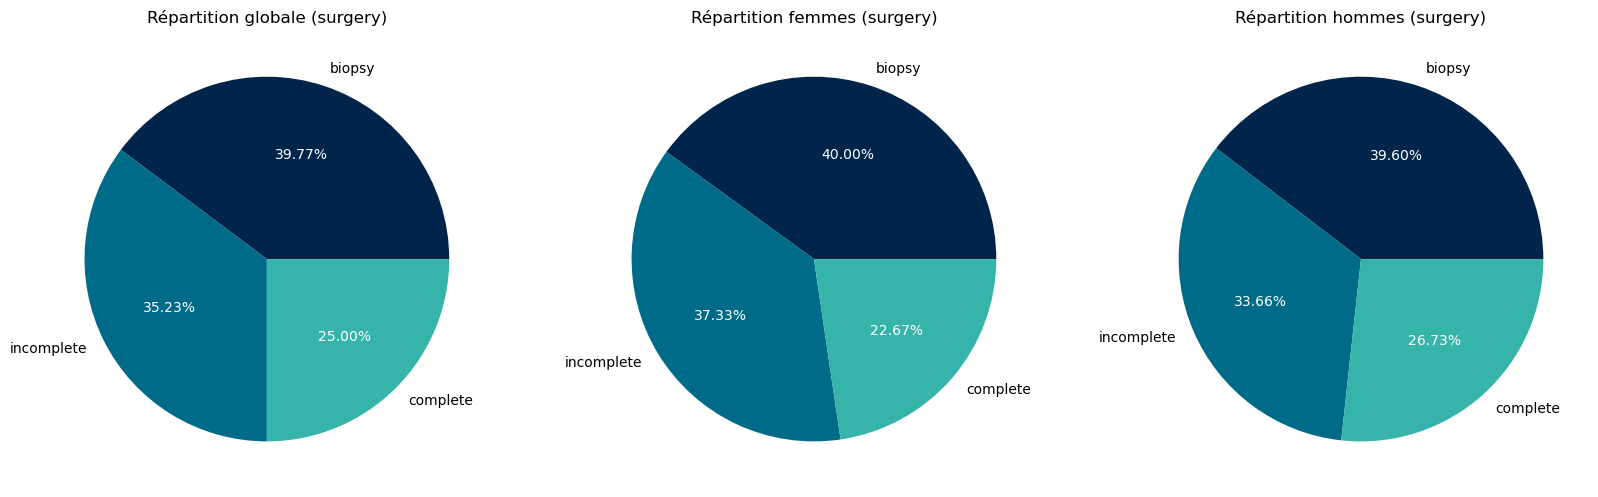

In [196]:
ExplorationDonneesPreliminaires_diagramme(df, 'surgery')

Valeur minimale de survival : 23
Valeur maximale de survival : 1600
Valeur moyenne de survival : 355.25
Valeur écart-type de survival : 261.59


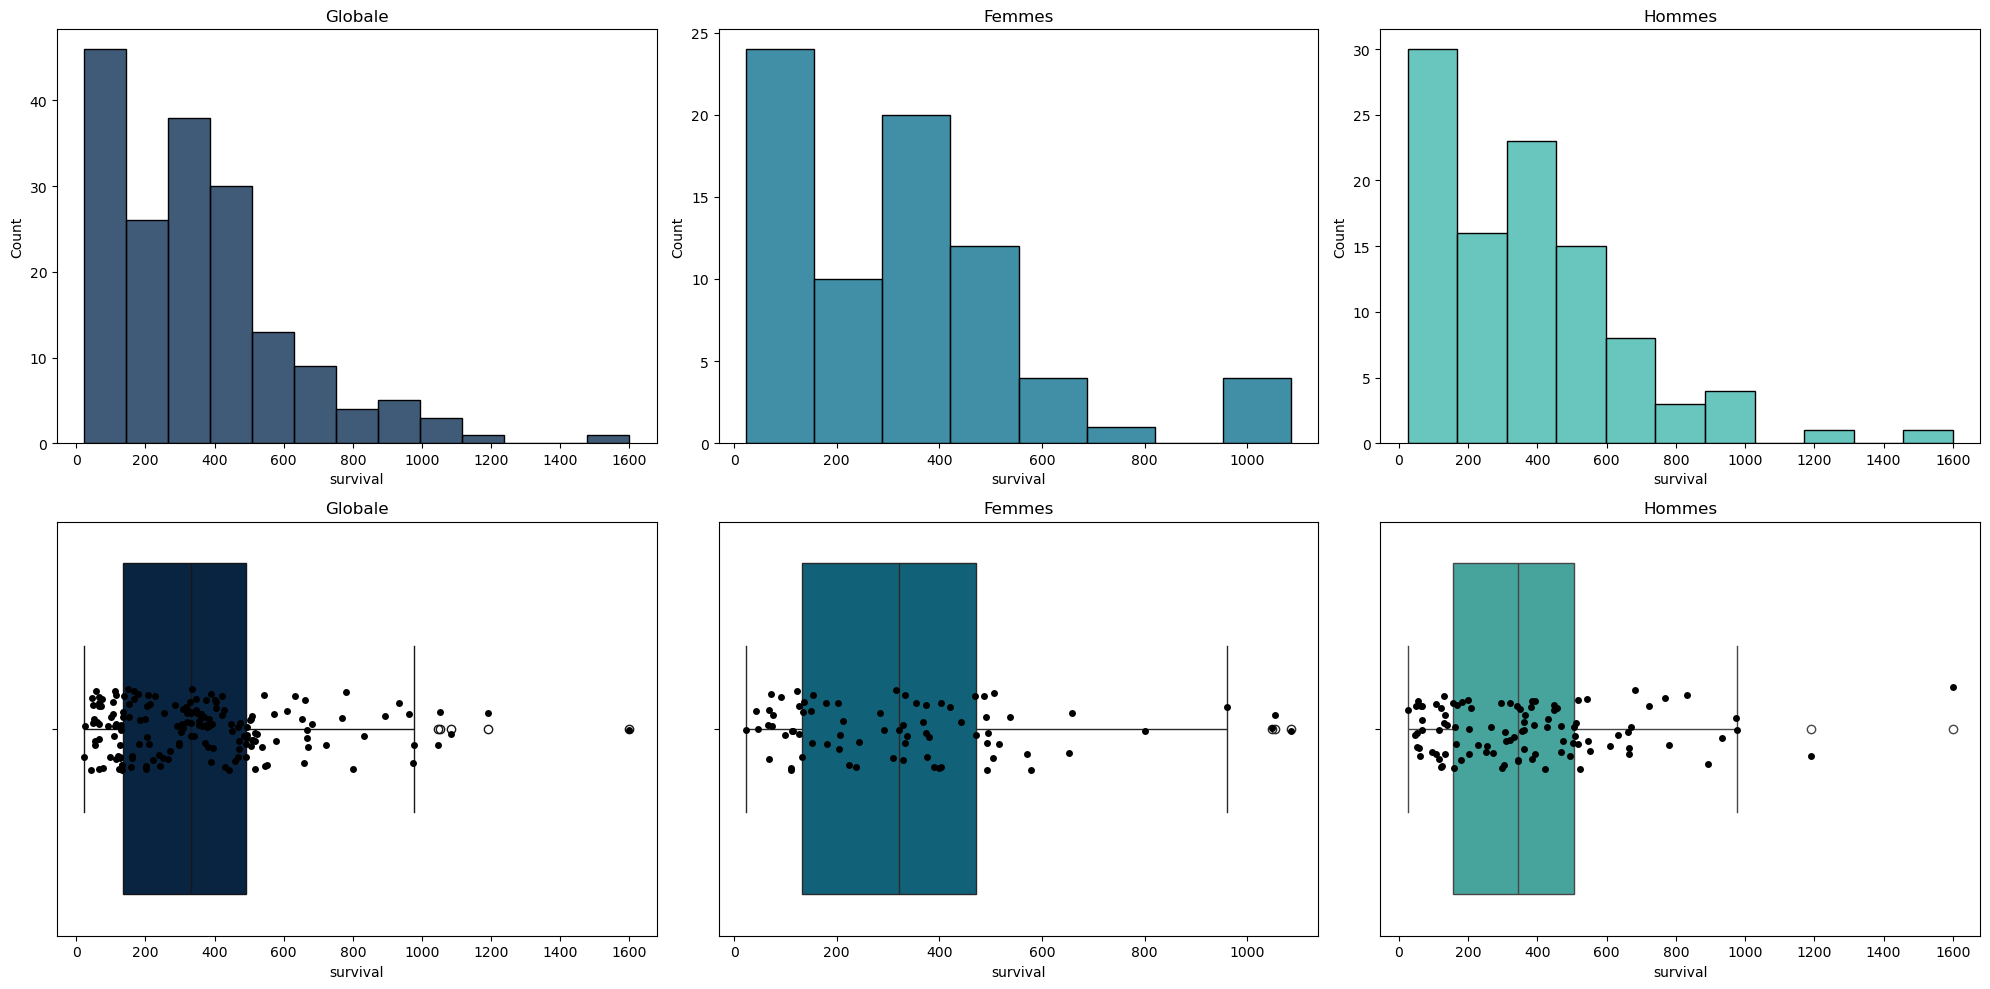

In [198]:
ExplorationDonneesPreliminaires_histplot_boxplot(df, 'survival')

ANOVA - Comparison of survival by surgery type:
F-statistic: 16.272202652103257
p-value: 3.346942943129593e-07

Descriptive statistics:

Biopsy:
Number of patients: 70
Mean survival: 238.49
Standard deviation survival: 191.64

Incomplete:
Number of patients: 62
Mean survival: 386.69
Standard deviation survival: 259.43

Complete:
Number of patients: 44
Mean survival: 496.70
Standard deviation survival: 282.83


C:\Users\DESMAL\AppData\Local\Temp\ipykernel_13112\1830359722.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='surgery_type', y='mean', data=summary_df, errorbar=None, order=order, palette=colors)


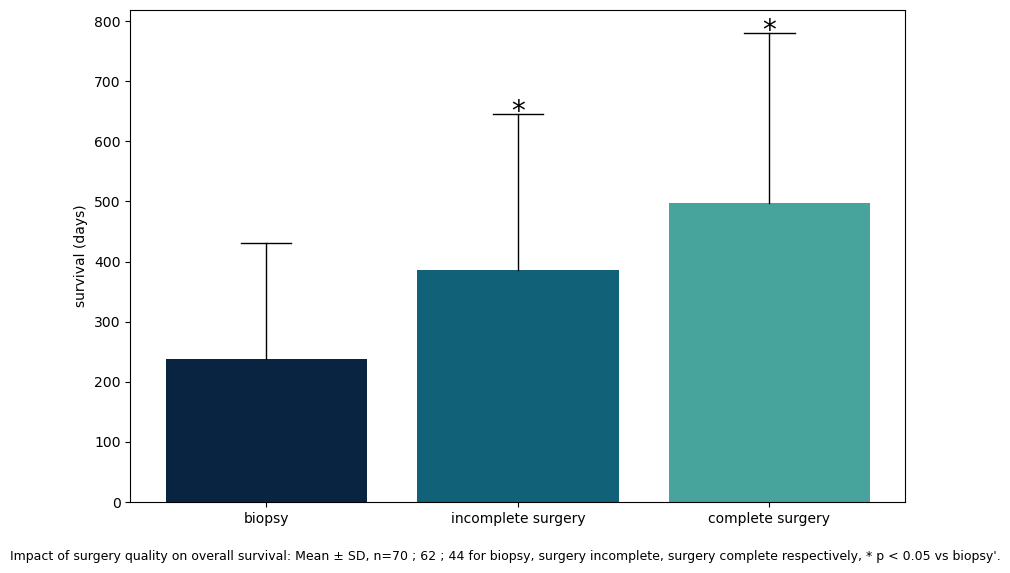

In [201]:
perform_anova_analysis(df, 'survival')